In [2]:
from __future__ import annotations

import gc
import gzip
import os
import subprocess
import threading
import time
from pathlib import Path
from typing import Callable, Any

import matplotlib.pyplot as plt
import polars as pl
import psutil

from griffith import Griffith

In [6]:
GTF_PATH = Path("tests/data/gencode.v50.chr_patch_hapl_scaff.basic.annotation.gtf")

DATASET_NAME = "GENCODE_v50_chr_patch_hapl_scaff_basic"
DIALECT = "gtf"

BENCHMARK_DIR = Path("benchmark_gencode_v50_basic")
OUT_DIR = BENCHMARK_DIR / "results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

GENCODE_ATTRIBUTES = [
    "gene_id",
    "gene_type",
    "gene_name",
    "level",
    "hgnc_id",
    "havana_gene",
    "transcript_id",
    "transcript_type",
    "transcript_name",
    "transcript_support_level",
    "tag",
    "havana_transcript",
    "exon_number",
    "exon_id",
    "protein_id",
    "ccdsid",
    "ont",
]

gf = Griffith.from_file(
    GTF_PATH,
    dialect="gtf",
    attribute_columns=GENCODE_ATTRIBUTES,
)

gf.collect().head()

seqid,source,feature,start,end,score,strand,phase,attributes,gene_id,gene_type,gene_name,level,hgnc_id,havana_gene,transcript_id,transcript_type,transcript_name,transcript_support_level,tag,havana_transcript,exon_number,exon_id,protein_id,ccdsid,ont
str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""chr1""","""HAVANA""","""gene""",11121,24894,null,"""+""",null,"""gene_id ""ENSG00000290825.2""; g…","""ENSG00000290825.2""","""lncRNA""","""DDX11L16""","""2""",null,null,null,null,null,null,"""overlaps_pseudogene""",null,null,null,null,null,null
"""chr1""","""HAVANA""","""transcript""",11426,14409,null,"""+""",null,"""gene_id ""ENSG00000290825.2""; t…","""ENSG00000290825.2""","""lncRNA""","""DDX11L16""","""2""",null,null,"""ENST00000832828.1""","""lncRNA""","""DDX11L16-264""",null,"""basic""",null,null,null,null,null,null
"""chr1""","""HAVANA""","""exon""",11426,11671,null,"""+""",null,"""gene_id ""ENSG00000290825.2""; t…","""ENSG00000290825.2""","""lncRNA""","""DDX11L16""","""2""",null,null,"""ENST00000832828.1""","""lncRNA""","""DDX11L16-264""",null,"""basic""",null,"""1""","""ENSE00004248702.1""",null,null,null
"""chr1""","""HAVANA""","""exon""",12010,12227,null,"""+""",null,"""gene_id ""ENSG00000290825.2""; t…","""ENSG00000290825.2""","""lncRNA""","""DDX11L16""","""2""",null,null,"""ENST00000832828.1""","""lncRNA""","""DDX11L16-264""",null,"""basic""",null,"""2""","""ENSE00004248735.1""",null,null,null
"""chr1""","""HAVANA""","""exon""",12613,12721,null,"""+""",null,"""gene_id ""ENSG00000290825.2""; t…","""ENSG00000290825.2""","""lncRNA""","""DDX11L16""","""2""",null,null,"""ENST00000832828.1""","""lncRNA""","""DDX11L16-264""",null,"""basic""",null,"""3""","""ENSE00003582793.1""",null,null,null


In [7]:
def file_size_mb(path: Path) -> float:
    return path.stat().st_size / 1024**2


file_info = pl.DataFrame(
    [
        {
            "dataset": DATASET_NAME,
            "path": str(GTF_PATH),
            "dialect": DIALECT,
            "file_size_mb": file_size_mb(GTF_PATH),
        }
    ]
)

file_info

dataset,path,dialect,file_size_mb
str,str,str,f64
"""GENCODE_v50_chr_patch_hapl_sca…","""tests/data/gencode.v50.chr_pat…","""gtf""",3109.718218


In [8]:
gf.frame.collect_schema()

Schema([('seqid', String),
        ('source', String),
        ('feature', String),
        ('start', Int64),
        ('end', Int64),
        ('score', String),
        ('strand', String),
        ('phase', String),
        ('attributes', String),
        ('gene_id', String),
        ('gene_type', String),
        ('gene_name', String),
        ('level', String),
        ('hgnc_id', String),
        ('havana_gene', String),
        ('transcript_id', String),
        ('transcript_type', String),
        ('transcript_name', String),
        ('transcript_support_level', String),
        ('tag', String),
        ('havana_transcript', String),
        ('exon_number', String),
        ('exon_id', String),
        ('protein_id', String),
        ('ccdsid', String),
        ('ont', String)])

In [10]:
def benchmark_operation(
    operation: str,
    func: Callable[[], Any],
    *,
    sample_interval: float = 0.05,
) -> tuple[dict[str, Any], Any]:
    """
    Benchmark a single operation.

    Tracks:
    - wall time
    - RSS memory before and after
    - peak RSS memory during execution
    - success/failure
    """
    gc.collect()

    process = psutil.Process(os.getpid())
    rss_before = process.memory_info().rss / 1024**2

    stop_event = threading.Event()
    rss_samples: list[float] = []

    def sample_memory() -> None:
        while not stop_event.is_set():
            rss_samples.append(process.memory_info().rss / 1024**2)
            time.sleep(sample_interval)

    sampler = threading.Thread(target=sample_memory)
    sampler.start()

    t0 = time.perf_counter()
    success = True
    error = None
    result = None

    try:
        result = func()
    except Exception as exc:
        success = False
        error = repr(exc)
    finally:
        elapsed = time.perf_counter() - t0
        stop_event.set()
        sampler.join()

    rss_after = process.memory_info().rss / 1024**2
    peak_rss = max(rss_samples + [rss_before, rss_after])

    record = {
        "dataset": DATASET_NAME,
        "operation": operation,
        "success": success,
        "wall_time_sec": elapsed,
        "rss_before_mb": rss_before,
        "rss_after_mb": rss_after,
        "peak_rss_mb": peak_rss,
        "rss_delta_mb": rss_after - rss_before,
        "peak_rss_delta_mb": peak_rss - rss_before,
        "error": error,
    }

    return record, result

In [11]:
def count_rows(gf: Griffith) -> int:
    return (
        gf.frame
        .select(pl.len().alias("n"))
        .collect()
        .item()
    )


def count_features(gf: Griffith) -> pl.DataFrame:
    return (
        gf.frame
        .group_by("feature")
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .collect()
    )


def attribute_completeness(
    gf: Griffith,
    total_rows: int,
    attributes: list[str],
) -> pl.DataFrame:
    schema_names = set(gf.frame.collect_schema().names())

    attrs = [
        attr
        for attr in attributes
        if attr in schema_names
    ]

    row = (
        gf.frame
        .select(
            [
                pl.col(attr).is_not_null().sum().alias(attr)
                for attr in attrs
            ]
        )
        .collect()
    )

    records = []

    for attr in attrs:
        n_non_null = int(row[attr][0])
        records.append(
            {
                "attribute": attr,
                "n_non_null": n_non_null,
                "fraction_non_null": n_non_null / total_rows if total_rows else 0.0,
            }
        )

    return (
        pl.DataFrame(records)
        .sort("fraction_non_null", descending=True)
    )


def gene_type_counts(gf: Griffith) -> pl.DataFrame:
    return (
        gf.frame
        .filter(
            (pl.col("feature") == "gene")
            & pl.col("gene_type").is_not_null()
        )
        .group_by("gene_type")
        .agg(pl.len().alias("n_genes"))
        .sort("n_genes", descending=True)
        .collect()
    )


def transcript_type_counts(gf: Griffith) -> pl.DataFrame:
    return (
        gf.frame
        .filter(
            (pl.col("feature") == "transcript")
            & pl.col("transcript_type").is_not_null()
        )
        .group_by("transcript_type")
        .agg(pl.len().alias("n_transcripts"))
        .sort("n_transcripts", descending=True)
        .collect()
    )


def exon_counts_per_transcript(gf: Griffith) -> pl.DataFrame:
    return (
        gf.frame
        .filter(
            (pl.col("feature") == "exon")
            & pl.col("transcript_id").is_not_null()
        )
        .group_by("transcript_id")
        .agg(
            pl.len().alias("n_exons"),
            pl.first("gene_id").alias("gene_id"),
            pl.first("gene_name").alias("gene_name"),
            pl.first("transcript_name").alias("transcript_name"),
            pl.first("transcript_type").alias("transcript_type"),
        )
        .sort("n_exons", descending=True)
        .collect()
    )


def tag_counts(gf: Griffith) -> pl.DataFrame:
    return (
        gf.frame
        .filter(pl.col("tag").is_not_null())
        .group_by("tag")
        .agg(pl.len().alias("n_rows"))
        .sort("n_rows", descending=True)
        .collect()
    )


def dmd_locus_subset(gf: Griffith) -> Griffith:
    """
    Broad DMD locus subset on GRCh38.

    This captures DMD and nearby annotation context.
    """
    return gf.filter(
        (pl.col("seqid") == "chrX")
        & (pl.col("start") <= 33_300_000)
        & (pl.col("end") >= 31_000_000)
    )


def dmd_gene_only_subset(gf: Griffith) -> Griffith:
    """
    DMD-only subset using gene_name or stable Ensembl gene ID prefix.
    """
    return gf.filter(
        (pl.col("gene_name") == "DMD")
        | (pl.col("gene_id").str.starts_with("ENSG00000198947"))
    )


def write_gtf_no_extra_quotes(gf: Griffith, out_path: Path) -> None:
    """
    Write valid GTF without CSV-style quoting around column 9.
    """
    gf.to_gff(rebuild_attributes=True).sink_csv(
        out_path,
        separator="\t",
        include_header=False,
        quote_style="never",
    )

In [12]:
metrics_records = []

rec, n_rows = benchmark_operation(
    "count_rows",
    lambda: count_rows(gf),
)
metrics_records.append(rec)

rec, feature_counts = benchmark_operation(
    "count_feature_types",
    lambda: count_features(gf),
)
metrics_records.append(rec)

rec, attr_comp = benchmark_operation(
    "attribute_completeness",
    lambda: attribute_completeness(gf, n_rows, GENCODE_ATTRIBUTES),
)
metrics_records.append(rec)

rec, gene_types = benchmark_operation(
    "gene_type_counts",
    lambda: gene_type_counts(gf),
)
metrics_records.append(rec)

rec, transcript_types = benchmark_operation(
    "transcript_type_counts",
    lambda: transcript_type_counts(gf),
)
metrics_records.append(rec)

rec, exon_counts = benchmark_operation(
    "exon_counts_per_transcript",
    lambda: exon_counts_per_transcript(gf),
)
metrics_records.append(rec)

rec, tags = benchmark_operation(
    "tag_counts",
    lambda: tag_counts(gf),
)
metrics_records.append(rec)

rec, dmd_locus_gf = benchmark_operation(
    "create_dmd_locus_lazy_subset",
    lambda: dmd_locus_subset(gf),
)
metrics_records.append(rec)

rec, dmd_locus_rows = benchmark_operation(
    "count_dmd_locus_rows",
    lambda: count_rows(dmd_locus_gf),
)
metrics_records.append(rec)

rec, dmd_gene_gf = benchmark_operation(
    "create_dmd_gene_only_lazy_subset",
    lambda: dmd_gene_only_subset(gf),
)
metrics_records.append(rec)

rec, dmd_gene_rows = benchmark_operation(
    "count_dmd_gene_only_rows",
    lambda: count_rows(dmd_gene_gf),
)
metrics_records.append(rec)

dmd_locus_out = OUT_DIR / "gencode_v50_basic_DMD_locus.gtf"
dmd_gene_out = OUT_DIR / "gencode_v50_basic_DMD_gene_only.gtf"

rec, _ = benchmark_operation(
    "write_dmd_locus_gtf",
    lambda: write_gtf_no_extra_quotes(dmd_locus_gf, dmd_locus_out),
)
metrics_records.append(rec)

rec, _ = benchmark_operation(
    "write_dmd_gene_only_gtf",
    lambda: write_gtf_no_extra_quotes(dmd_gene_gf, dmd_gene_out),
)
metrics_records.append(rec)

metrics = pl.DataFrame(metrics_records)

summary = pl.DataFrame(
    [
        {
            "dataset": DATASET_NAME,
            "path": str(GTF_PATH),
            "dialect": DIALECT,
            "file_size_mb": file_size_mb(GTF_PATH),
            "n_rows": n_rows,
            "n_feature_types": feature_counts.height,
            "n_dmd_locus_rows": dmd_locus_rows,
            "n_dmd_gene_only_rows": dmd_gene_rows,
            "dmd_locus_output_path": str(dmd_locus_out),
            "dmd_gene_only_output_path": str(dmd_gene_out),
        }
    ]
)

summary

dataset,path,dialect,file_size_mb,n_rows,n_feature_types,n_dmd_locus_rows,n_dmd_gene_only_rows,dmd_locus_output_path,dmd_gene_only_output_path
str,str,str,f64,i64,i64,i64,i64,str,str
"""GENCODE_v50_chr_patch_hapl_sca…","""tests/data/gencode.v50.chr_pat…","""gtf""",3109.718218,7597775,8,1760,1702,"""benchmark_gencode_v50_basic/re…","""benchmark_gencode_v50_basic/re…"


In [13]:
metrics.sort("operation")

dataset,operation,success,wall_time_sec,rss_before_mb,rss_after_mb,peak_rss_mb,rss_delta_mb,peak_rss_delta_mb,error
str,str,bool,f64,f64,f64,f64,f64,f64,null
"""GENCODE_v50_chr_patch_hapl_sca…","""attribute_completeness""",true,6.252083,7412.226562,13685.589844,13986.46875,6273.363281,6574.242188,null
"""GENCODE_v50_chr_patch_hapl_sca…","""count_dmd_gene_only_rows""",true,3.415516,7566.824219,10868.359375,13703.726562,3301.535156,6136.902344,null
"""GENCODE_v50_chr_patch_hapl_sca…","""count_dmd_locus_rows""",true,2.807408,11003.484375,8817.230469,11028.875,-2186.253906,25.390625,null
"""GENCODE_v50_chr_patch_hapl_sca…","""count_feature_types""",true,2.816313,7128.378906,7412.226562,10467.03125,283.847656,3338.652344,null
"""GENCODE_v50_chr_patch_hapl_sca…","""count_rows""",true,0.306736,7187.867188,7128.378906,9778.539062,-59.488281,2590.671875,null
…,…,…,…,…,…,…,…,…,…
"""GENCODE_v50_chr_patch_hapl_sca…","""gene_type_counts""",true,3.495402,13662.734375,9948.304688,13826.859375,-3714.429688,164.125,null
"""GENCODE_v50_chr_patch_hapl_sca…","""tag_counts""",true,3.456067,11058.921875,11095.414062,13768.828125,36.492188,2709.90625,null
"""GENCODE_v50_chr_patch_hapl_sca…","""transcript_type_counts""",true,3.058556,9945.957031,10275.585938,13389.914062,329.628906,3443.957031,null


In [15]:
feature_counts

feature,n
str,u32
"""exon""",3205552
"""CDS""",2662961
"""UTR""",758991
"""transcript""",360315
"""start_codon""",261897
"""stop_codon""",261515
"""gene""",86411
"""Selenocysteine""",133


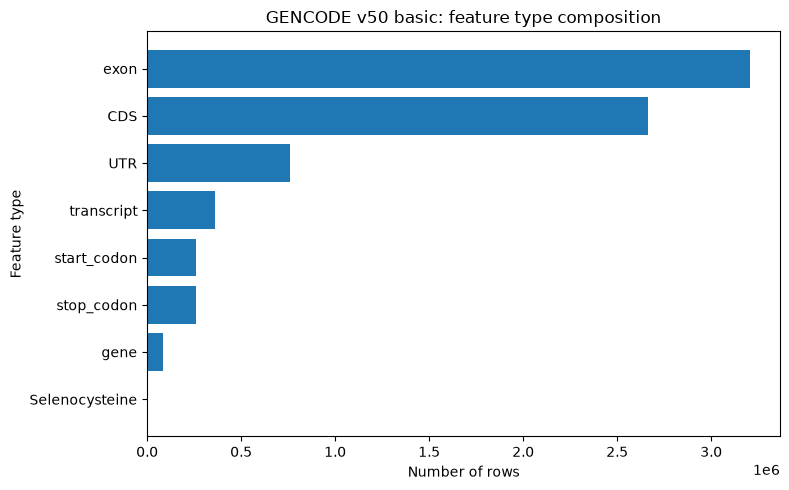

In [17]:
top_features = feature_counts.head(25)

plt.figure(figsize=(8, 5))
plt.barh(
    top_features["feature"].to_list()[::-1],
    top_features["n"].to_list()[::-1],
)
plt.xlabel("Number of rows")
plt.ylabel("Feature type")
plt.title("GENCODE v50 basic: feature type composition")
plt.tight_layout()
plt.show()

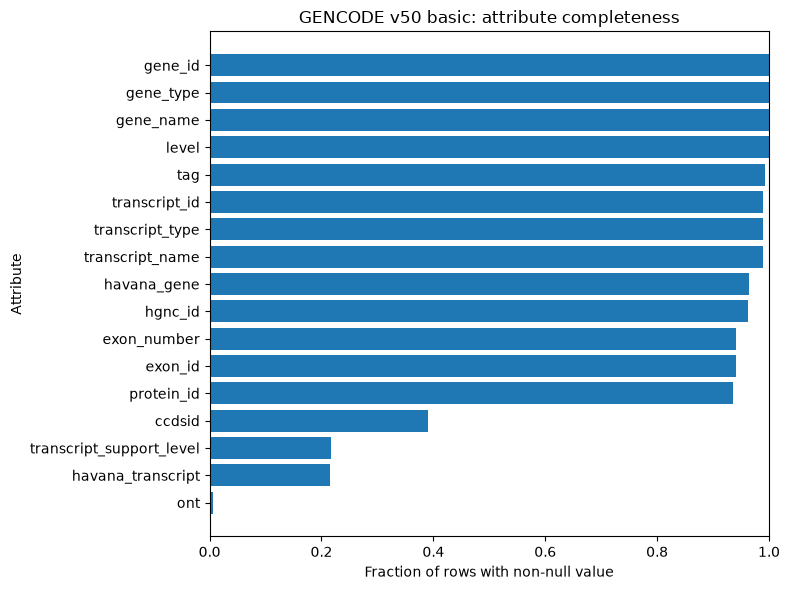

In [18]:
top_attrs = attr_comp.head(25)

plt.figure(figsize=(8, 6))
plt.barh(
    top_attrs["attribute"].to_list()[::-1],
    top_attrs["fraction_non_null"].to_list()[::-1],
)
plt.xlabel("Fraction of rows with non-null value")
plt.ylabel("Attribute")
plt.title("GENCODE v50 basic: attribute completeness")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

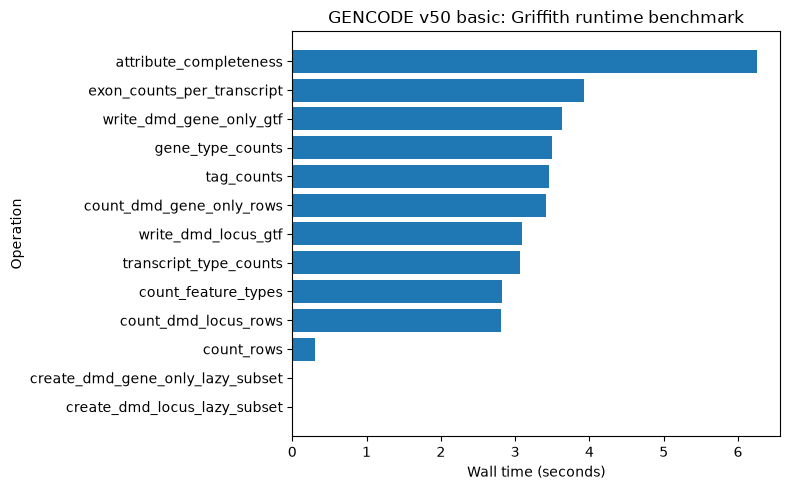

In [19]:
runtime_df = (
    metrics
    .filter(pl.col("success"))
    .sort("wall_time_sec", descending=True)
)

plt.figure(figsize=(8, 5))
plt.barh(
    runtime_df["operation"].to_list()[::-1],
    runtime_df["wall_time_sec"].to_list()[::-1],
)
plt.xlabel("Wall time (seconds)")
plt.ylabel("Operation")
plt.title("GENCODE v50 basic: Griffith runtime benchmark")
plt.tight_layout()
plt.show()

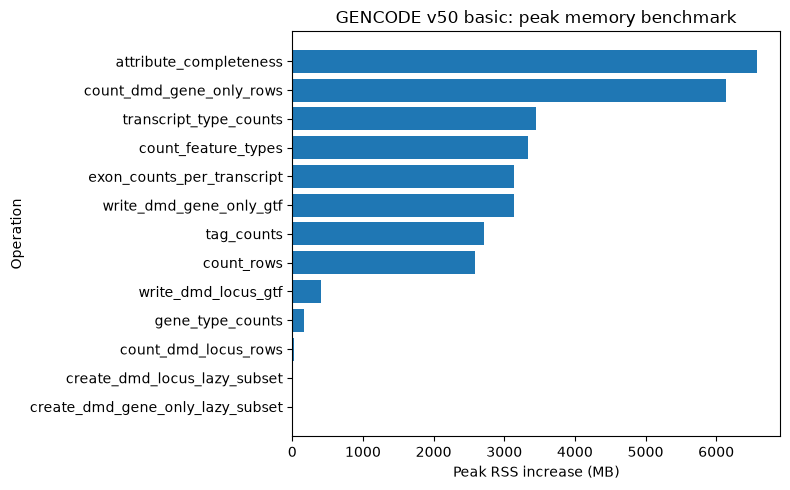

In [20]:
memory_df = (
    metrics
    .filter(pl.col("success"))
    .sort("peak_rss_delta_mb", descending=True)
)

plt.figure(figsize=(8, 5))
plt.barh(
    memory_df["operation"].to_list()[::-1],
    memory_df["peak_rss_delta_mb"].to_list()[::-1],
)
plt.xlabel("Peak RSS increase (MB)")
plt.ylabel("Operation")
plt.title("GENCODE v50 basic: peak memory benchmark")
plt.tight_layout()
plt.show()

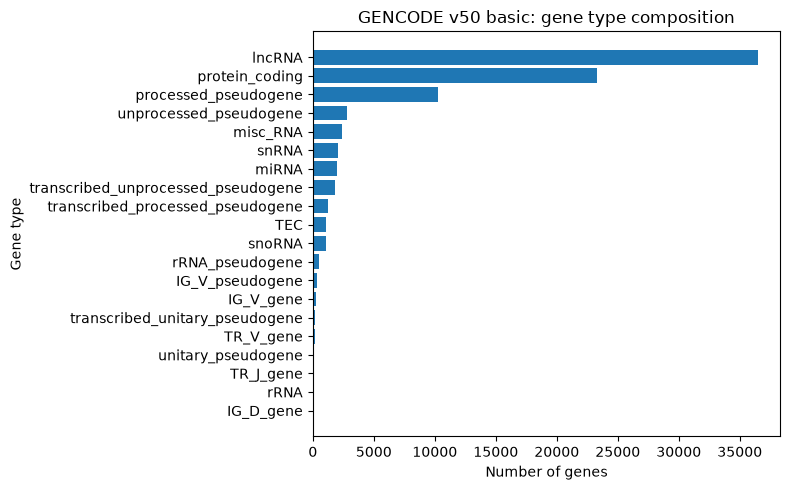

In [21]:
top_gene_types = gene_types.head(20)

plt.figure(figsize=(8, 5))
plt.barh(
    top_gene_types["gene_type"].to_list()[::-1],
    top_gene_types["n_genes"].to_list()[::-1],
)
plt.xlabel("Number of genes")
plt.ylabel("Gene type")
plt.title("GENCODE v50 basic: gene type composition")
plt.tight_layout()
plt.show()

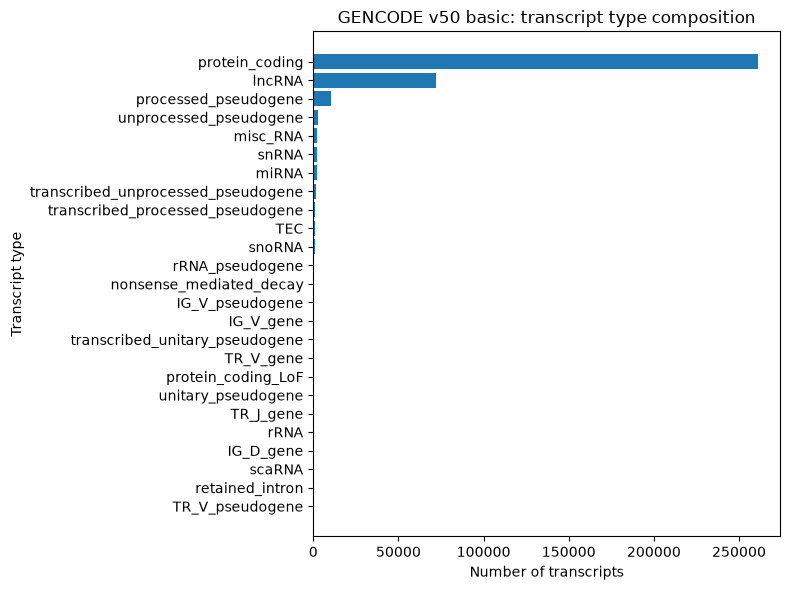

In [22]:
top_transcript_types = transcript_types.head(25)

plt.figure(figsize=(8, 6))
plt.barh(
    top_transcript_types["transcript_type"].to_list()[::-1],
    top_transcript_types["n_transcripts"].to_list()[::-1],
)
plt.xlabel("Number of transcripts")
plt.ylabel("Transcript type")
plt.title("GENCODE v50 basic: transcript type composition")
plt.tight_layout()
plt.show()

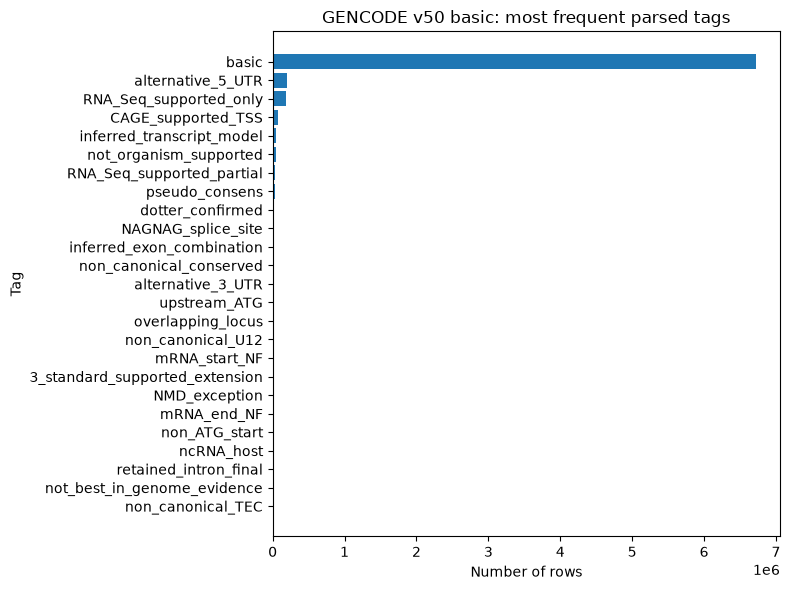

In [23]:
if tags.height > 0:
    top_tags = tags.head(25)

    plt.figure(figsize=(8, 6))
    plt.barh(
        top_tags["tag"].to_list()[::-1],
        top_tags["n_rows"].to_list()[::-1],
    )
    plt.xlabel("Number of rows")
    plt.ylabel("Tag")
    plt.title("GENCODE v50 basic: most frequent parsed tags")
    plt.tight_layout()
    plt.show()
else:
    print("No tag values parsed.")

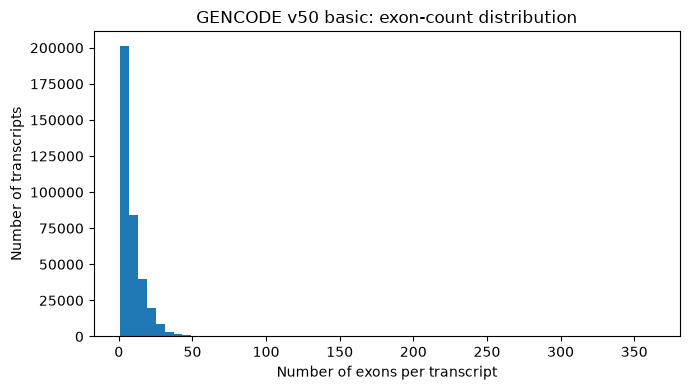

In [24]:
plt.figure(figsize=(7, 4))
plt.hist(exon_counts["n_exons"].to_list(), bins=60)
plt.xlabel("Number of exons per transcript")
plt.ylabel("Number of transcripts")
plt.title("GENCODE v50 basic: exon-count distribution")
plt.tight_layout()
plt.show()

In [25]:
dmd_preview_columns = [
    col
    for col in [
        "seqid",
        "source",
        "feature",
        "start",
        "end",
        "strand",
        "gene_id",
        "gene_name",
        "gene_type",
        "transcript_id",
        "transcript_name",
        "transcript_type",
        "exon_number",
        "exon_id",
        "tag",
    ]
    if col in dmd_locus_gf.frame.collect_schema().names()
]

dmd_locus_preview = (
    dmd_locus_gf.frame
    .select(dmd_preview_columns)
    .limit(50)
    .collect()
)

dmd_locus_preview

seqid,source,feature,start,end,strand,gene_id,gene_name,gene_type,transcript_id,transcript_name,transcript_type,exon_number,exon_id,tag
str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str
"""chrX""","""HAVANA""","""gene""",31014709,31070685,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""",null,null,null,null,null,null
"""chrX""","""HAVANA""","""transcript""",31014709,31070685,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""","""ENST00000727252.1""","""ENST00000727252""","""lncRNA""",null,null,"""basic"""
"""chrX""","""HAVANA""","""exon""",31014709,31015108,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""","""ENST00000727252.1""","""ENST00000727252""","""lncRNA""","""1""","""ENSE00004052638.1""","""basic"""
"""chrX""","""HAVANA""","""exon""",31049807,31049905,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""","""ENST00000727252.1""","""ENST00000727252""","""lncRNA""","""2""","""ENSE00004052640.1""","""basic"""
"""chrX""","""HAVANA""","""exon""",31069524,31069757,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""","""ENST00000727252.1""","""ENST00000727252""","""lncRNA""","""3""","""ENSE00004052641.1""","""basic"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chrX""","""HAVANA""","""exon""",31173539,31173604,"""-""","""ENSG00000198947.19""","""DMD""","""protein_coding""","""ENST00000681026.1""","""DMD-244""","""protein_coding""","""3""","""ENSE00003915925.1""","""CAGE_supported_TSS"""
"""chrX""","""HAVANA""","""exon""",31172348,31172413,"""-""","""ENSG00000198947.19""","""DMD""","""protein_coding""","""ENST00000681026.1""","""DMD-244""","""protein_coding""","""4""","""ENSE00003910628.1""","""CAGE_supported_TSS"""
"""chrX""","""HAVANA""","""CDS""",31172348,31172403,"""-""","""ENSG00000198947.19""","""DMD""","""protein_coding""","""ENST00000681026.1""","""DMD-244""","""protein_coding""","""4""","""ENSE00003910628.1""","""CAGE_supported_TSS"""


In [28]:
dmd_feature_counts = (
    dmd_locus_gf.frame
    .group_by("feature")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .collect()
)

dmd_feature_counts

feature,n
str,u32
"""exon""",804
"""CDS""",723
"""UTR""",114
"""transcript""",44
"""stop_codon""",30
"""start_codon""",29
"""gene""",16


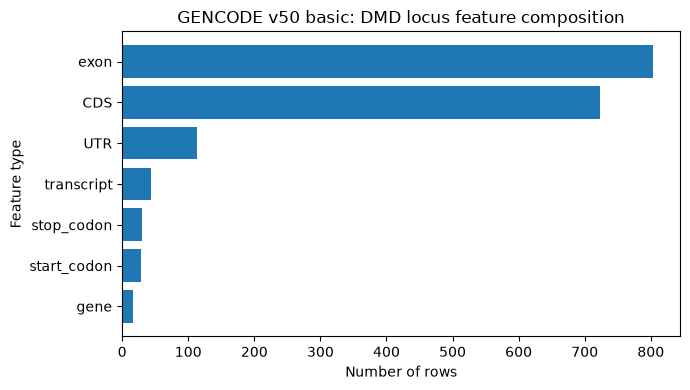

In [29]:
plt.figure(figsize=(7, 4))
plt.barh(
    dmd_feature_counts["feature"].to_list()[::-1],
    dmd_feature_counts["n"].to_list()[::-1],
)
plt.xlabel("Number of rows")
plt.ylabel("Feature type")
plt.title("GENCODE v50 basic: DMD locus feature composition")
plt.tight_layout()
plt.show()

In [30]:
dmd_exon_counts = (
    dmd_gene_gf.frame
    .filter(
        (pl.col("feature") == "exon")
        & pl.col("transcript_id").is_not_null()
    )
    .group_by("transcript_id")
    .agg(
        pl.len().alias("n_exons"),
        pl.first("transcript_name").alias("transcript_name"),
        pl.first("transcript_type").alias("transcript_type"),
    )
    .sort("n_exons", descending=True)
    .collect()
)

dmd_exon_counts

transcript_id,n_exons,transcript_name,transcript_type
str,u32,str,str
"""ENST00001135528.1""",79,"""DMD-295""","""protein_coding"""
"""ENST00000378677.7""",79,"""DMD-207""","""protein_coding"""
"""ENST00000357033.9""",79,"""DMD-203""","""protein_coding"""
"""ENST00000619831.6""",51,"""DMD-227""","""protein_coding"""
"""ENST00000378707.8""",36,"""DMD-211""","""protein_coding"""
…,…,…,…
"""ENST00000681026.1""",9,"""DMD-244""","""protein_coding"""
"""ENST00000680557.1""",8,"""DMD-240""","""protein_coding"""
"""ENST00000679437.1""",8,"""DMD-231""","""protein_coding"""


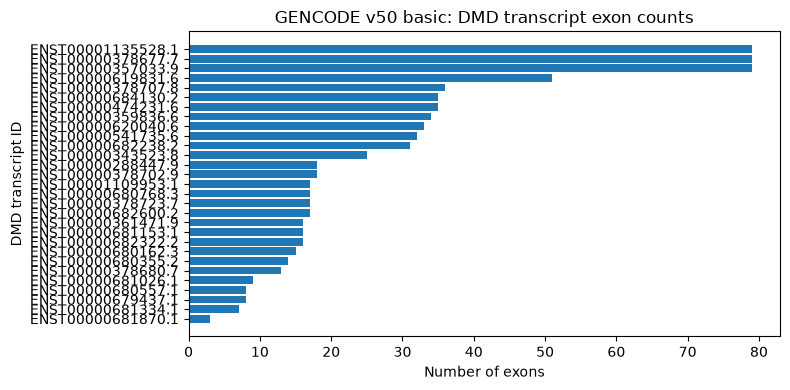

In [31]:
plt.figure(figsize=(8, 4))
plt.barh(
    dmd_exon_counts["transcript_id"].to_list()[::-1],
    dmd_exon_counts["n_exons"].to_list()[::-1],
)
plt.xlabel("Number of exons")
plt.ylabel("DMD transcript ID")
plt.title("GENCODE v50 basic: DMD transcript exon counts")
plt.tight_layout()
plt.show()

In [32]:
rec, dmd_roundtrip = benchmark_operation(
    "roundtrip_load_dmd_locus",
    lambda: Griffith.from_file(
        dmd_locus_out,
        dialect="gtf",
        attribute_columns=GENCODE_ATTRIBUTES,
    ),
)
metrics_records.append(rec)

if not rec["success"]:
    raise RuntimeError(rec["error"])

rec, dmd_roundtrip_rows = benchmark_operation(
    "roundtrip_count_dmd_locus_rows",
    lambda: count_rows(dmd_roundtrip),
)
metrics_records.append(rec)

print(f"Original DMD locus rows: {dmd_locus_rows:,}")
print(f"Round-trip DMD locus rows: {dmd_roundtrip_rows:,}")

assert dmd_locus_rows == dmd_roundtrip_rows

Original DMD locus rows: 1,760
Round-trip DMD locus rows: 1,760


In [33]:
(
    dmd_roundtrip.frame
    .select(dmd_preview_columns)
    .limit(20)
    .collect()
)

seqid,source,feature,start,end,strand,gene_id,gene_name,gene_type,transcript_id,transcript_name,transcript_type,exon_number,exon_id,tag
str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str
"""chrX""","""HAVANA""","""gene""",31014709,31070685,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""",null,null,null,null,null,null
"""chrX""","""HAVANA""","""transcript""",31014709,31070685,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""","""ENST00000727252.1""","""ENST00000727252""","""lncRNA""",null,null,"""basic"""
"""chrX""","""HAVANA""","""exon""",31014709,31015108,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""","""ENST00000727252.1""","""ENST00000727252""","""lncRNA""","""1""","""ENSE00004052638.1""","""basic"""
"""chrX""","""HAVANA""","""exon""",31049807,31049905,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""","""ENST00000727252.1""","""ENST00000727252""","""lncRNA""","""2""","""ENSE00004052640.1""","""basic"""
"""chrX""","""HAVANA""","""exon""",31069524,31069757,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""","""ENST00000727252.1""","""ENST00000727252""","""lncRNA""","""3""","""ENSE00004052641.1""","""basic"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chrX""","""HAVANA""","""transcript""",31071768,31198592,"""+""","""ENSG00000297249.1""","""ENSG00000297249""","""lncRNA""","""ENST00000746482.1""","""ENST00000746482""","""lncRNA""",null,null,"""basic"""
"""chrX""","""HAVANA""","""exon""",31071768,31071848,"""+""","""ENSG00000297249.1""","""ENSG00000297249""","""lncRNA""","""ENST00000746482.1""","""ENST00000746482""","""lncRNA""","""1""","""ENSE00004087460.1""","""basic"""
"""chrX""","""HAVANA""","""exon""",31117709,31117854,"""+""","""ENSG00000297249.1""","""ENSG00000297249""","""lncRNA""","""ENST00000746482.1""","""ENST00000746482""","""lncRNA""","""2""","""ENSE00004087461.1""","""basic"""


In [34]:
rec, validation_errors = benchmark_operation(
    "validate_parent_child",
    lambda: gf.validate_parent_child(),
)

metrics_records.append(rec)

print(rec)

if rec["success"]:
    print(f"Validation errors: {validation_errors.height:,}")
    validation_errors.head(20)
else:
    print(rec["error"])

{'dataset': 'GENCODE_v50_chr_patch_hapl_scaff_basic', 'operation': 'validate_parent_child', 'success': True, 'wall_time_sec': 16.385066207963973, 'rss_before_mb': 7525.08984375, 'rss_after_mb': 20352.046875, 'peak_rss_mb': 26163.39453125, 'rss_delta_mb': 12826.95703125, 'peak_rss_delta_mb': 18638.3046875, 'error': None}
Validation errors: 0
